In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = 1 
alpha = 0.1 
gamma = 0.5
epsilon = 0.01
iapp = 0.5 
v0 = 0.0
w0 = 0.0

tf = 5 #tempo final 
h = [0.01,0.001] #passos de tempo 


In [2]:
def f(v): 
    return A*v *(v - alpha) * (1 - v)

def sistemaDeEquacoes(estado):
    v, w = estado
    dvdt = 1/epsilon * (f(v) - w + iapp)
    dwdt = v - gamma*w 
    return np.array([dvdt, dwdt])


def sistemaDeEquacoes2(estado):
    v, w = estado
    dvdt = 1/epsilon * (f(v) - w - w0+ iapp)
    dwdt = v - gamma*w - v0
    return np.array([dvdt, dwdt])



def euler(funcao,y0,t,h):
    n = len(t)
    sol = np.zeros((n,len(y0)))
    sol[0] = y0
    for i in range(n-1):
        derivadas = funcao(sol[i])
        sol[i+1] = sol[i] + derivadas * h
    
    return sol

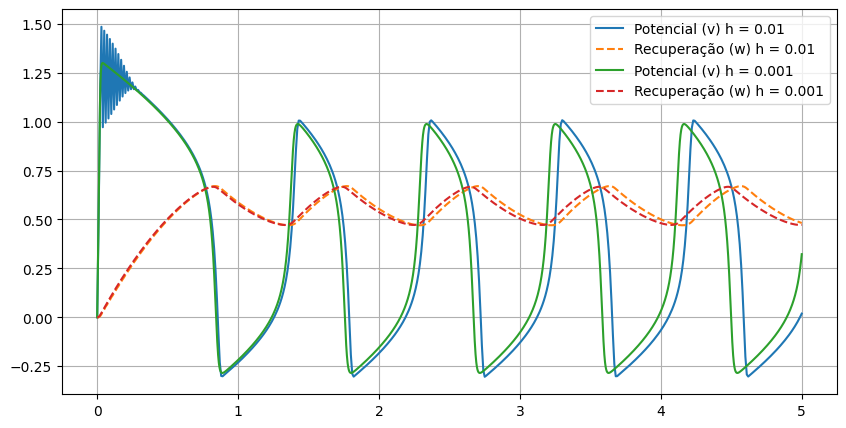

In [3]:
plt.figure(figsize=(10,5))
for i in h:
    t = np.arange(0, tf + i, i)
    
    solucao = euler(sistemaDeEquacoes,[v0, w0], t, i)
    
    plt.plot(t, solucao[:,0], label='Potencial (v) h = {}'.format(i))
    plt.plot(t, solucao[:,1], label='Recuperação (w) h = {}'.format(i), linestyle='--')


plt.legend()
plt.grid(True)
plt.show()

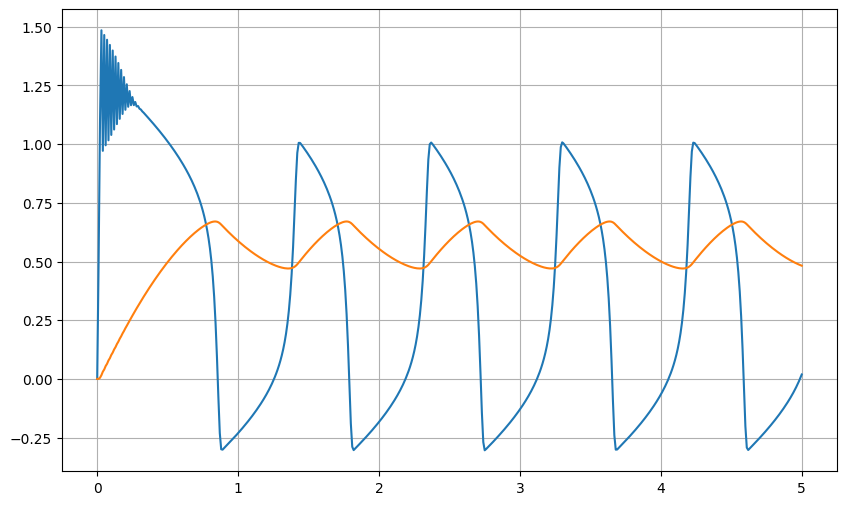

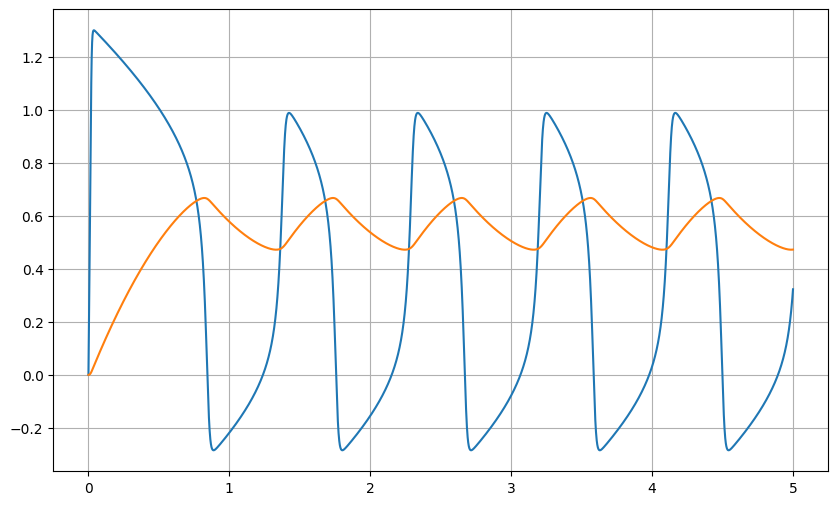

In [4]:
for i in h:
    t = np.arange(0, tf + i, i)
    plt.figure(figsize=(10,6))
    plt.grid(True)
    solucao2 = euler(sistemaDeEquacoes2, [v0, w0], t, i)
    plt.plot(t, solucao2[:,0]) 
    plt.plot(t, solucao2[:,1]) 
    plt.show()